## RFM Cohort Analysis

In [1]:
# import library
import numpy  as np         # linear algebra
import pandas as pd      # data processing, CSV file I/O (e.g. pd.read_CSV)
import datetime as dt

# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For Machine Learning Algorithm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#PureCode Al:Fux errors|Fix errors with context| X
df = pd.read_excel(r"C:\Users\acer\Downloads\Online Retail.xlsx")

In [2]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## Check and Clean Missing Data

In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df = df.dropna(subset=['CustomerID'])

In [6]:
df.isnull().sum().sum()

np.int64(0)

## Check & Clean Duplicates Data

In [7]:
df.duplicated().sum()

np.int64(5225)

In [8]:
df = df.drop_duplicates()

In [9]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,401604.000000,401604,401604.000000,401604.000000
mean,12.183273,2011-07-10 12:08:23.848567552,3.474064,15281.160818
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13939.000000
50%,5.000000,2011-07-29 15:40:00,1.950000,15145.000000
75%,12.000000,2011-10-20 11:58:30,3.750000,16784.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,250.283037,NaN,69.764035,1714.006089


In [10]:
df = df[(df['Quantity']>0) & (df['UnitPrice']>0)]
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,392692.000000,392692,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,180.492832,NaN,22.241836,1713.539549


In [11]:
df.shape

(392692, 8)

## Cohort Analysis

In [12]:
def get_month(x): return dt.datetime(x.year, x.month,1)
df['InvoiceMonth'] = df['InvoiceDate'].apply(get_month)
grouping = df.groupby('CustomerID')['InvoiceMonth']
df['CohortMonth'] = grouping.transform('min')
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,2011-12-01,2011-08-01
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,2011-12-01,2011-08-01
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12-01,2011-08-01
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12-01,2011-08-01
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,2011-12-01,2011-08-01


In [13]:
def get_month_int (dframe, column):
    year = dframe[column].dt.year
    month = dframe[column].dt.month
    day = dframe[column].dt.day
    return year, month, day

invoice_year, invoice_month,_ = get_month_int(df, 'InvoiceMonth')
cohort_year, cohort_month,_ = get_month_int(df, 'CohortMonth')

year_diff = invoice_year - cohort_year
month_diff = invoice_month - cohort_month

df['CohortIndex'] = year_diff * 12 + month_diff + 1

In [14]:
#Count monthly active customers from each cohort 
grouping = df.groupby(['CohortMonth', 'CohortIndex'])
cohort_data = grouping['CustomerID'].apply(pd.Series.nunique)
#Return number of unique elements in the object.
cohort_data = cohort_data.reset_index()
cohort_counts = cohort_data.pivot(index = 'CohortMonth', columns = 'CohortIndex', values = 'CustomerID')
cohort_counts

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02-01,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03-01,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04-01,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05-01,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06-01,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# Retention table
cohort_size = cohort_counts.iloc[:, 0]

retention = cohort_counts.divide(cohort_size, axis=0)

retention.round(3) * 100

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,100.0,36.6,32.3,38.4,36.3,39.8,36.3,34.9,35.4,39.5,37.4,50.3,26.6
2011-01-01,100.0,22.1,26.6,23.0,32.1,28.8,24.7,24.2,30.0,32.6,36.5,11.8,NaN
2011-02-01,100.0,18.7,18.7,28.4,27.1,24.7,25.3,27.9,24.7,30.5,6.8,NaN,NaN
2011-03-01,100.0,15.0,25.2,19.9,22.3,16.8,26.8,23.0,27.9,8.6,NaN,NaN,NaN
2011-04-01,100.0,21.3,20.3,21.0,19.7,22.7,21.7,26.0,7.3,NaN,NaN,NaN,NaN
2011-05-01,100.0,19.0,17.3,17.3,20.8,23.2,26.4,9.5,NaN,NaN,NaN,NaN,NaN
2011-06-01,100.0,17.4,15.7,26.4,23.1,33.5,9.5,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,100.0,18.1,20.7,22.3,27.1,11.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,100.0,20.7,24.9,24.3,12.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Visuliazation

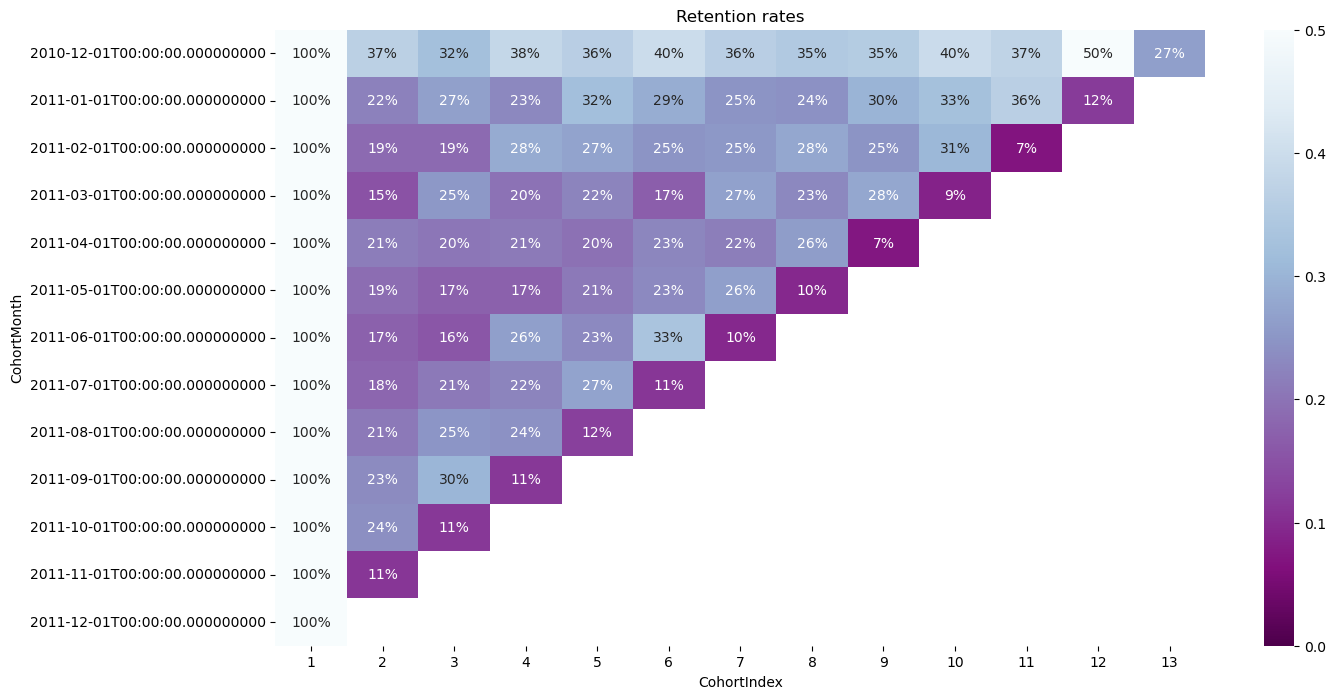

In [16]:
# Build the heatmap
plt.figure(figsize = (15, 8))
plt.title('Retention rates')
sns.heatmap(data = retention, annot = True, fmt = '.0%', vmin = 0.0, vmax = 0.5, cmap = "BuPu_r")
plt.show()

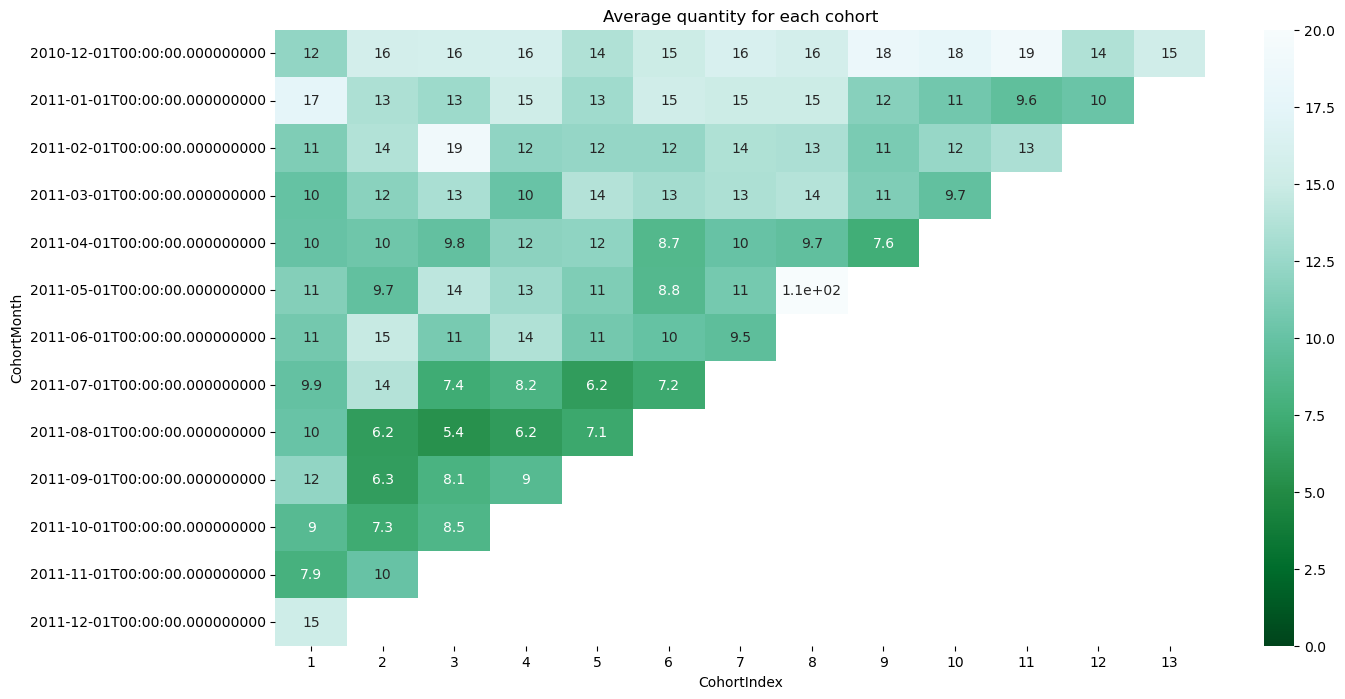

In [17]:
# Average quantity for each cohort
grouping = df.groupby(['CohortMonth', 'CohortIndex'])
cohort_data = grouping['Quantity'].mean()
cohort_data = cohort_data.reset_index()
average_quantity = cohort_data.pivot(index = 'CohortMonth', columns = 'CohortIndex', values = 'Quantity')
average_quantity.round(1)

# Build the heatmap
plt.figure(figsize = (15, 8))
plt.title('Average quantity for each cohort')
sns.heatmap(data = average_quantity, annot = True, vmin = 0.0, vmax = 20, cmap = "BuGn_r")
plt.show()

## Statistical Measurements

In [18]:
# New Total Sum Column
df['TotalSum'] = df['UnitPrice']* df['Quantity']

# Data preparation steps
print('Min Invoice Date:', df.InvoiceDate.dt.date.min(),'max Invoice Date:',
      df.InvoiceDate.dt.date.max())

df.head(3)      

Min Invoice Date: 2010-12-01 max Invoice Date: 2011-12-09


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex,TotalSum
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,2010-12-01,1,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,2010-12-01,1,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01,2010-12-01,1,22.00


In [19]:
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days = 1)
snapshot_date
# The last day of purchase in total is 09 DEC, 2011.  To calculate the day periods,
# let's set one day after the last one, or
# 10 DEC as a snapshort_date.  We will cound the diff days with snapshot_date.

Timestamp('2011-12-10 12:50:00')

In [20]:
# Calculate RFM metrics
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalSum': 'sum'
})

# Rename columns
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'MonetaryValue'
}, inplace=True)

# Final RFM values
rfm.head()

,Recency,Frequency,MonetaryValue
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [21]:
# Building RFM segements
r_labels = range(4, 0, -1)
f_labels = range(1, 5)
m_labels = range(1, 5)
r_quartiles = pd.qcut(rfm['Recency'], q = 4, labels = r_labels)
f_quartiles = pd.qcut(rfm['Frequency'], q = 4, labels = f_labels)
m_quartiles = pd.qcut(rfm['MonetaryValue'], q = 4, labels = m_labels)
rfm = rfm.assign(R = r_quartiles, F = f_quartiles, M = m_quartiles)

# Build RFM Segment and RFM Score
def add_rfm(x) : return str(x['R']) + str(x['F']) + str(x['M'])
rfm['RFM_Segment'] = rfm.apply(add_rfm, axis = 1)
rfm['RFM_Score'] = rfm[['R','F','M']].sum(axis = 1)

rfm.head()

,Recency,Frequency,MonetaryValue,R,F,M,RFM_Segment,RFM_Score
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,1.01.04.0,6
12347.0,2,182,4310.00,4,4,4,4.04.04.0,12
12348.0,75,31,1797.24,2,2,4,2.02.04.0,8
12349.0,19,73,1757.55,3,3,4,3.03.04.0,10
12350.0,310,17,334.40,1,1,2,1.01.02.0,4


## Analysing RFM Segments


In [22]:
rfm.groupby(['RFM_Segment']).size().sort_values(ascending = False)[:5]

RFM_Segment
4.04.04.0    450
1.01.01.0    381
3.04.04.0    217
1.02.02.0    206
2.01.01.0    179
dtype: int64

In [23]:
rfm.groupby('RFM_Score').agg({'Recency': 'mean', 'Frequency': 'mean', 'MonetaryValue': ['mean', 'count']}).round(1)

Recency Frequency MonetaryValue      
             mean      mean          mean count
RFM_Score                                      
3           260.7       8.2         157.4   381
4           177.2      13.6         240.0   388
5           152.9      21.2         366.6   518
6            95.9      27.9         820.8   457
7            79.6      38.0         758.1   463
8            64.1      56.0         987.3   454
9            45.9      78.7        1795.1   414
10           32.4     110.5        2056.4   426
11           21.3     186.9        4062.0   387
12            7.2     367.8        9285.9   450

In [24]:
def segments(df):
    if df['RFM_Score'] > 9:
        return 'Gold'
    elif (df['RFM_Score'] > 5) and (df['RFM_Score'] <= 9):
        return 'Silver'
    else:
        return 'Bronze'


# Create General Segment
rfm['General_Segment'] = rfm.apply(segments, axis=1)

# Analyze each segment
segment_summary = rfm.groupby('General_Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'MonetaryValue': ['mean', 'count']
}).round(1)

segment_summary

Recency Frequency MonetaryValue      
                   mean      mean          mean count
General_Segment                                      
Bronze            192.2      15.1         266.5  1287
Gold               20.1     225.6        5246.8  1263
Silver             72.0      49.4        1072.4  1788

## Data Pre-processing

In [25]:
rfm_rfm = rfm[['Recency', 'Frequency', 'MonetaryValue']]
print(rfm_rfm.describe())

           Recency    Frequency  MonetaryValue
count  4338.000000  4338.000000    4338.000000
mean     92.536422    90.523744    2048.688081
std     100.014169   225.506968    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000    17.000000     306.482500
50%      51.000000    41.000000     668.570000
75%     142.000000    98.000000    1660.597500
max     374.000000  7676.000000  280206.020000


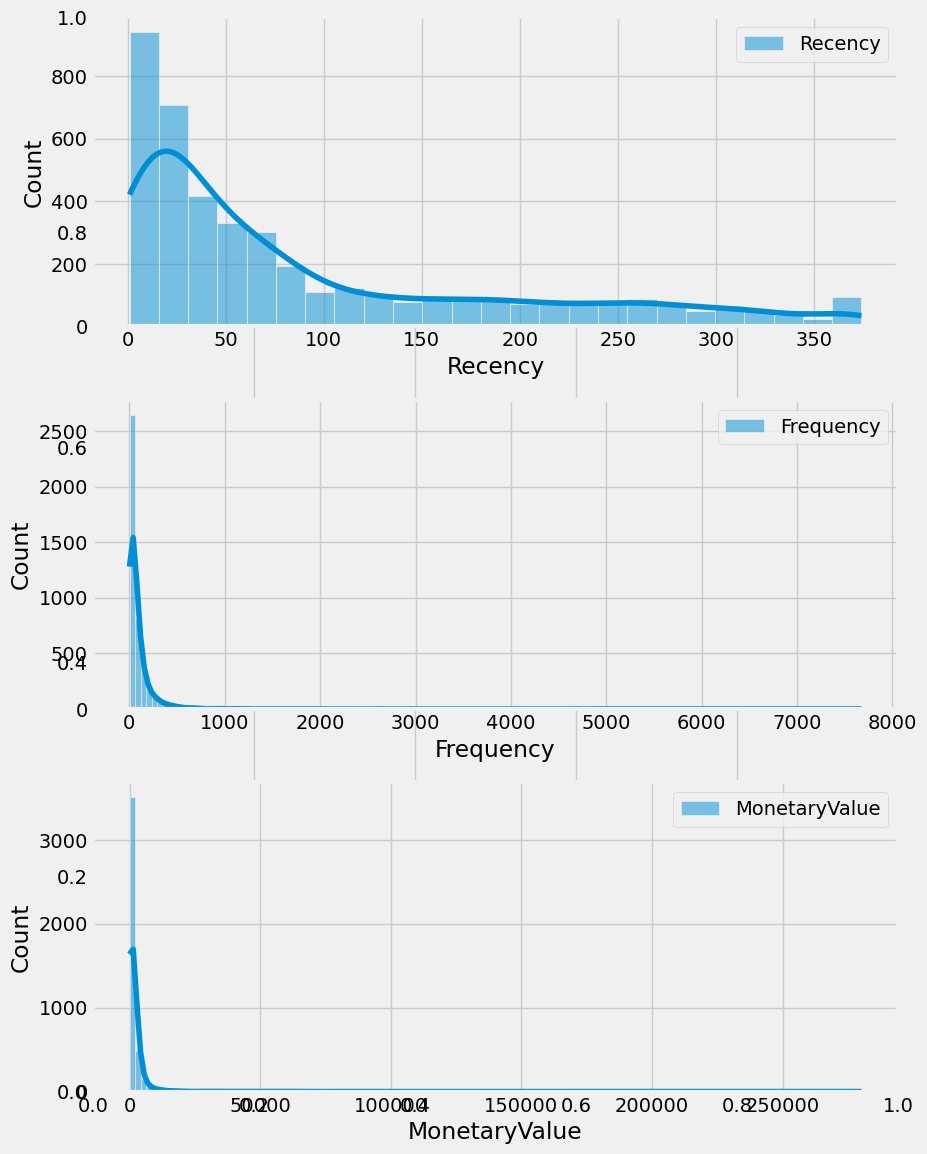

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')

f, ax = plt.subplots(figsize=(10, 12))

plt.subplot(3, 1, 1)
sns.histplot(rfm['Recency'], kde=True, label='Recency')
plt.legend()

plt.subplot(3, 1, 2)
sns.histplot(rfm['Frequency'], kde=True, label='Frequency')
plt.legend()

plt.subplot(3, 1, 3)
sns.histplot(rfm['MonetaryValue'], kde=True, label='MonetaryValue')
plt.legend()

plt.tight_layout()
plt.show()

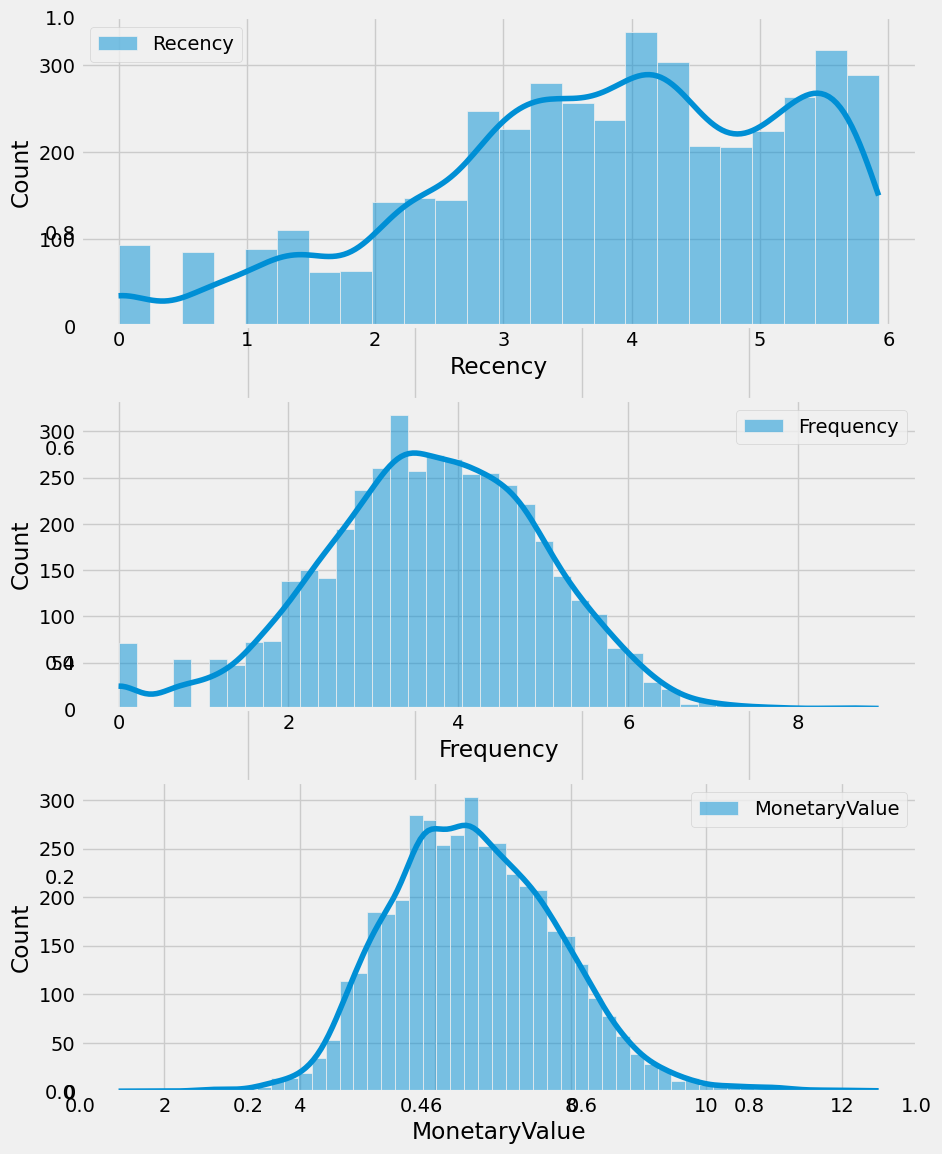

In [27]:
# Unskew the data with log transformation
rfm_log = rfm[['Recency', 'Frequency', 'MonetaryValue']].apply(
    np.log, axis=1
).round(3)

# Plot the distribution of RFM values
f, ax = plt.subplots(figsize=(10, 12))

plt.subplot(3, 1, 1)
sns.histplot(rfm_log['Recency'], kde=True, label='Recency')
plt.legend()

plt.subplot(3, 1, 2)
sns.histplot(rfm_log['Frequency'], kde=True, label='Frequency')
plt.legend()

plt.subplot(3, 1, 3)
sns.histplot(rfm_log['MonetaryValue'], kde=True, label='MonetaryValue')
plt.legend()

plt.tight_layout()
plt.show()

## K - Means Implementation

In [28]:
# Normalize the variables with StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler
scaler.fit(rfm_log)

# Transform the data and store it for clustering
rfm_normalized = scaler.transform(rfm_log)

# Check the normalized data
rfm_normalized[:5]

array([[ 1.40998159, -2.77997064,  3.70023933],
       [-2.14657818,  1.16036535,  1.41349442],
       [ 0.38364809, -0.17983348,  0.71994094],
       [-0.57496137,  0.46830788,  0.70250303],
       [ 1.37507228, -0.63489534, -0.613267  ]])

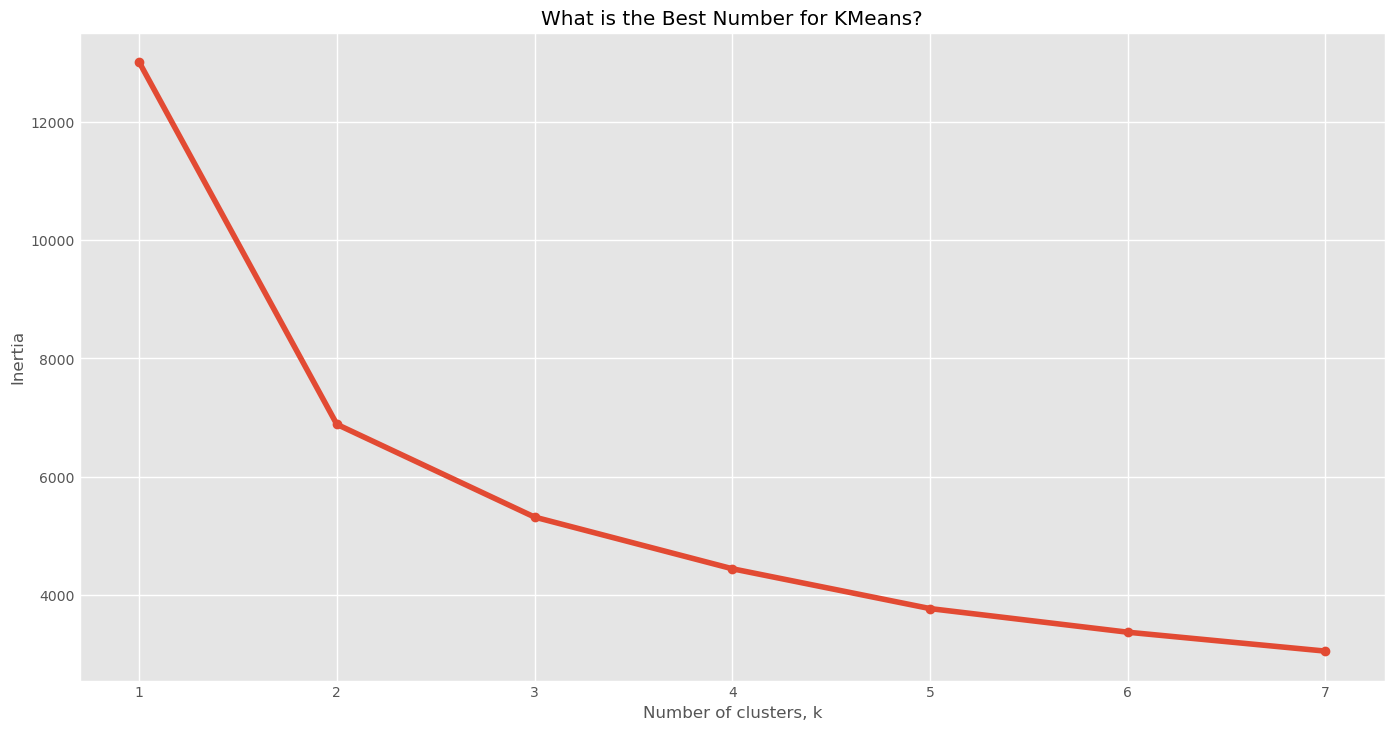

In [30]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# First: Get the Best KMeans
ks = range(1, 8)
inertias = []

for k in ks:
    # Create a KMeans cluster
    kc = KMeans(n_clusters=k, random_state=1, n_init=10)
    kc.fit(rfm_normalized)
    inertias.append(kc.inertia_)

# Plot ks vs inertias
f, ax = plt.subplots(figsize=(15, 8))

plt.plot(ks, inertias, '-o')
plt.xlabel('Number of clusters, k')
plt.ylabel('Inertia')
plt.xticks(ks)

plt.style.use('ggplot')
plt.title('What is the Best Number for KMeans?')

plt.show()

In [31]:
from sklearn.cluster import KMeans

# Clustering
kc = KMeans(n_clusters=3, random_state=1, n_init=10)
kc.fit(rfm_normalized)

# Create cluster labels
cluster_labels = kc.labels_

# Add cluster labels to the original RFM DataFrame
rfm_rfm_k3 = rfm.assign(k_Cluster=cluster_labels)

# Calculate average RFM values and cluster size
cluster_summary = rfm_rfm_k3.groupby('k_Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'MonetaryValue': ['mean', 'count']
}).round(0)

cluster_summary

Recency Frequency MonetaryValue      
             mean      mean          mean count
k_Cluster                                      
0            69.0      66.0        1183.0  1850
1            13.0     262.0        6610.0   945
2           170.0      15.0         294.0  1543

In [32]:
# Convert normalized RFM data into a DataFrame
rfm_normalized = pd.DataFrame(
    rfm_normalized,
    index=rfm.index,
    columns=['Recency', 'Frequency', 'MonetaryValue']
)

# Add cluster labels
rfm_normalized['k_Cluster'] = kc.labels_

# Add general customer segments
rfm_normalized['General_Segment'] = rfm['General_Segment']

# Reset index to bring CustomerID back as a column
rfm_normalized.reset_index(inplace=True)

# Melt the data into long format
rfm_melt = pd.melt(
    rfm_normalized,
    id_vars=['CustomerID', 'General_Segment', 'k_Cluster'],
    value_vars=['Recency', 'Frequency', 'MonetaryValue'],
    var_name='Metric',
    value_name='Value'
)

# Display first 5 rows
rfm_melt.head()

,CustomerID,General_Segment,k_Cluster,Metric,Value
0,12346.0,Silver,0,Recency,1.409982
1,12347.0,Gold,1,Recency,-2.146578
2,12348.0,Silver,0,Recency,0.383648
3,12349.0,Gold,0,Recency,-0.574961
4,12350.0,Bronze,2,Recency,1.375072


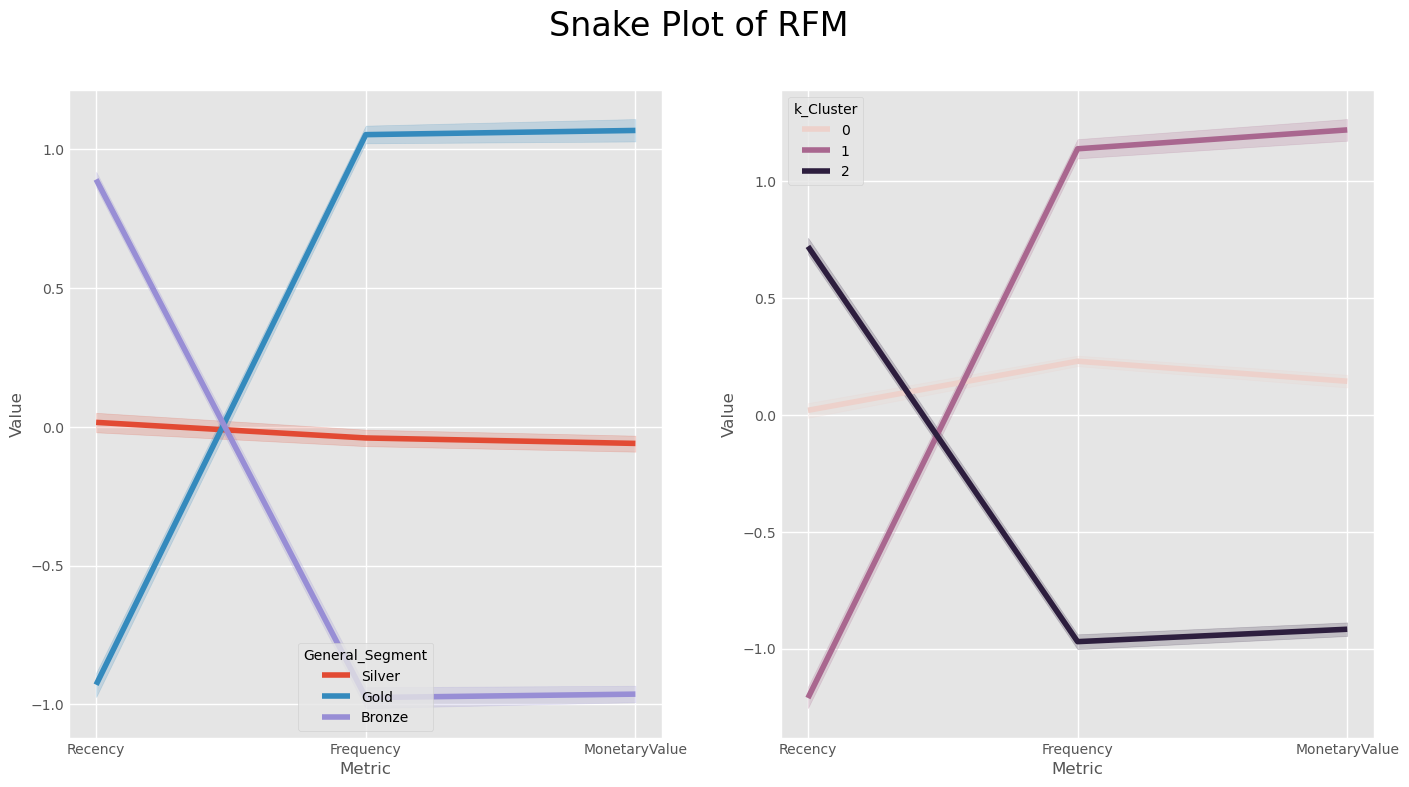

In [33]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 8))
sns.lineplot(x = 'Metric', y = 'Value', hue = 'General_Segment', data = rfm_melt, ax = ax1)

# a snake plot with k-Means
sns.lineplot(x = 'Metric', y = 'Value', hue = 'k_Cluster', data = rfm_melt, ax = ax2)

plt.suptitle("Snake Plot of RFM", fontsize = 24)   #make title fontsize subtitle
plt.show()

In [34]:
# Calculate average RFM values for each cluster
cluster_avg = rfm_rfm_k3.groupby('k_Cluster').mean(numeric_only=True)

# Calculate average RFM values for the whole population
population_avg = rfm[['Recency', 'Frequency', 'MonetaryValue']].mean()

# Calculate relative importance
relative_imp = cluster_avg[['Recency', 'Frequency', 'MonetaryValue']] / population_avg - 1

# Round the values
relative_imp.round(2)

,Recency,Frequency,MonetaryValue
k_Cluster,,,
0,-0.26,-0.27,-0.42
1,-0.86,1.89,2.23
2,0.83,-0.83,-0.86


In [35]:
# the mean value in total 
total_avg = rfm.iloc[:, 0:3].mean()
# calculate the proportional gap with total mean
cluster_avg = rfm.groupby('General_Segment')[['Recency', 'Frequency', 'MonetaryValue']].mean().iloc[:, 0:3]
prop_rfm = cluster_avg / total_avg - 1
prop_rfm.round(2)

,Recency,Frequency,MonetaryValue
General_Segment,,,
Bronze,1.08,-0.83,-0.87
Gold,-0.78,1.49,1.56
Silver,-0.22,-0.45,-0.48


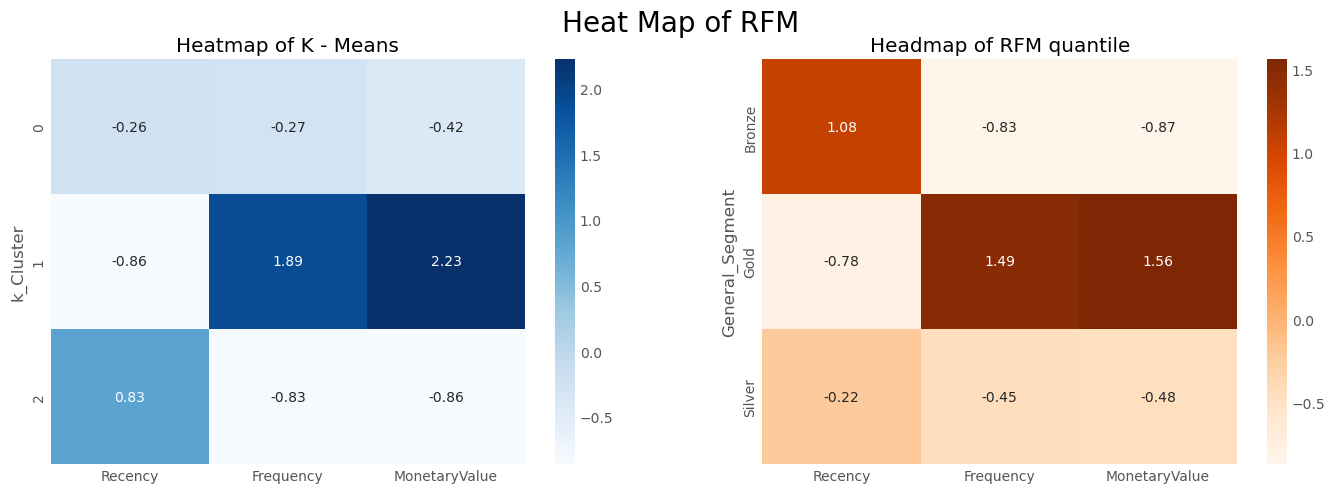

In [36]:
# heatmap with RFM
f, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 5))
sns.heatmap(data = relative_imp, annot = True, fmt = '.2f', cmap = 'Blues', ax = ax1)
ax1.set(title = "Heatmap of K - Means")

# a snake plot with K - Means
sns.heatmap(prop_rfm, cmap = 'Oranges', fmt = '.2f', annot = True, ax = ax2)
ax2.set(title = "Headmap of RFM quantile")

plt.suptitle("Heat Map of RFM", fontsize = 20)  # make title fontsize subtitle 

plt.show()